In [55]:
import numpy as np

%load_ext autoreload
%autoreload 2

from pycamcal.primitives.pose import Pose3D, R3D
from pycamcal.primitives.math_helpers import get_random_rotation

from pycamcal.camera_model.camera_model import CameraModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
camera_model = CameraModel.from_fov((800, 600), (80, 60), distortion=None, degrees=True)

world_points_all = np.random.uniform(low=(-10, -10, -10), high=(+10, +10, +10), size=(100, 3))

camera_pose = Pose3D(
    t=np.random.normal(loc=(0,0,0), scale=3),
    R=get_random_rotation(np.random.uniform(0, 2*np.pi))
)


In [57]:
# visualize scene

import open3d

from pycamcal.simulation.viz_utils import visualize_camera_positioning

visualize_camera_positioning(
    [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points_all))],
    camera_model, [camera_pose]
)

(600.0, 0.0)

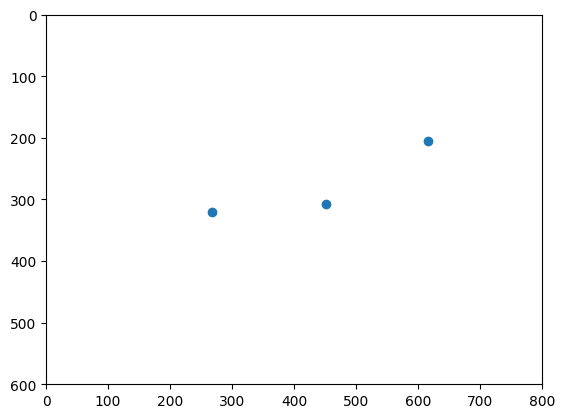

In [58]:
# simulate camera capture

from matplotlib import pyplot as plt

np.set_printoptions(suppress=True)

points_external = camera_pose.inv().apply(world_points_all)
image_points = camera_model.project_into_image(points_external)

# include only those points which are in front of the camera and in frame
mask_in_front = points_external[:,2] > 0
mask_in_frame = np.all((image_points > 0) & (image_points <= camera_model.res_xy), axis=-1)

mask = mask_in_front & mask_in_frame
image_points = image_points[mask]
world_points = world_points_all[mask]

plt.scatter(*image_points[:3].T)
plt.xlim(0, camera_model.res_xy[0])
plt.ylim(camera_model.res_xy[1], 0)

In [59]:
# inverse projection sanity check
rays_local = camera_model.cast_ray_from_pixel(image_points)
rays_world = camera_pose.R.apply(rays_local)

rays_world_true = world_points - camera_pose.t

for i in range(3):
    print(rays_world[i])
    print(rays_world_true[i] / np.linalg.norm(rays_world_true[i]))

[-0.19856504  0.5608088   0.803782  ]
[-0.19856504  0.5608088   0.803782  ]
[-0.33537763  0.24581335  0.909449  ]
[-0.33537766  0.2458134   0.90944904]
[-0.27639663 -0.12500942  0.9528787 ]
[-0.2763967  -0.12500937  0.95287853]


In [60]:
# visualize_camera_positioning(
#     [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points[:3]))],
#     camera_model, [camera_pose]
# )

In [61]:
from pycamcal.calibration.pnp import solve_PnP, solve_P3P

solutions_russ = solve_P3P(world_points[:3], image_points[:3], camera_model)

print("-"*50)

print(f"P3P Results ({len(solutions_russ)} solutions)")

for sol in solutions_russ:
    pos_error = np.linalg.norm(camera_pose.t - sol.t)
    att_error = np.rad2deg((camera_pose.R * sol.R.inv()).magnitude())

    print(f"t = {sol.t}, r = {sol.R.r}")
    print(f"pos error: {pos_error:0.3f} meters")
    print(f"att error: {att_error:0.3f} degrees")
    print()

roots: [1.04788993+0.1897659j 1.04788993-0.1897659j 1.05135829+0.j
 0.78588324+0.j       ]
ranges: 8.548230812895321 8.957604986860307 7.98807148310071
ranges: 8.523731843153014 8.961496146011415 8.026743138492757
ranges: 8.261211135458593 6.492347360671342 8.34025702457583
--------------------------------------------------
P3P Results (3 solutions)
t = [-3.6271129  -5.3379393   0.64119035], r = [-0.39202464 -0.07806791  1.7791762 ]
pos error: 0.090 meters
att error: 0.583 degrees

t = [-3.6251047 -5.2523355  0.6125942], r = [-0.3843604  -0.08677185  1.7808259 ]
pos error: 0.000 meters
att error: 0.001 degrees

t = [-12.933844  -2.27168   10.109789], r = [1.5896777 1.1029602 1.0182797]
pos error: 13.628 meters
att error: 123.117 degrees



In [62]:
# import cv2

# num_solutions, rvecs, tvecs = cv2.solveP3P(
#     np.array(world_points[:3]), np.array(image_points[:3]),
#     np.array(camera_model.get_intrinsics_matrix()), None,
#     cv2.SOLVEPNP_P3P
# )

# solutions_opencv = [
#     Pose3D(t, R3D.from_rotvec(r))
#     for t, r in zip(tvecs, rvecs)
# ]

# for solution in solutions_opencv:
#     print(solution.t)
#     print(solution.R.as_euler("xyz"))
#     print()

In [63]:
visualize_camera_positioning(
    [open3d.geometry.PointCloud(open3d.utility.Vector3dVector(world_points[:3]))],
    camera_model, [camera_pose, *solutions_russ]
)

In [64]:
# true ranges:
np.linalg.norm(world_points[:3] - camera_pose.t, axis=-1)

array([8.523686, 8.961504, 8.026811], dtype=float32)